鸢尾花数据集 (Iris)
数据形状 (样本, 特征): (150, 4)

前5行:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

矩阵 A 的形状: (150, 4)
矩阵的秩: 4

协方差矩阵 (4x4):
[[ 0.686 -0.042  1.274  0.516]
 [-0.042  0.19  -0.33  -0.122]
 [ 1.274 -0.33   3.116  1.296]
 [ 0.516 -0.122  1.296  0.581]]


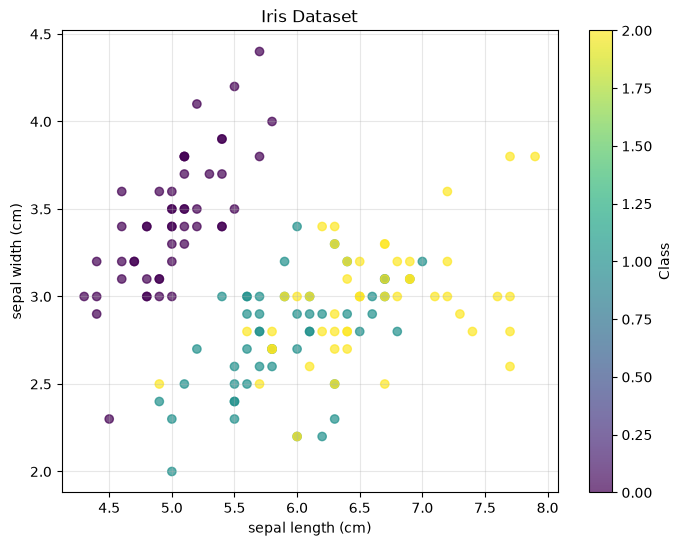


随机组合向量 x = [-1.53   1.29   1.703  0.831]
合成的特征 b (前5个值): [-0.739 -1.078 -0.685 -0.32  -0.457]
b 的维度: (150,)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# ---- 加载真实数据集：鸢尾花 (Iris) ----
iris = load_iris()
X = iris.data  # 特征矩阵，形状 (150, 4)
y = iris.target  # 标签，形状 (150,)

# 转换为 DataFrame 方便查看
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

print("=" * 60)
print("鸢尾花数据集 (Iris)")
print("=" * 60)
print(f"数据形状 (样本, 特征): {X.shape}")  # 输出: (150, 4)
print("\n前5行:")
print(df.head())

# ---- 我们的矩阵就是 X ----
A = X  # 150行 × 4列
print(f"\n矩阵 A 的形状: {A.shape}")
print(f"矩阵的秩: {np.linalg.matrix_rank(A)}")  # 输出: 4 (因为4个特征线性无关)

# ---- 用矩阵乘法计算协方差矩阵（中心化后） ----
# 中心化：减去均值
A_centered = A - A.mean(axis=0)  # (150, 4)
# 协方差矩阵 = (1/149) * A_centered^T @ A_centered
cov_matrix = (1 / (A.shape[0] - 1)) * (A_centered.T @ A_centered)
print("\n协方差矩阵 (4x4):")
print(cov_matrix.round(3))

# ---- 画出前两个特征的关系 ----
# 图表中使用英文
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Iris Dataset')
plt.colorbar(label='Class')
plt.grid(alpha=0.3)
plt.show()

# ---- 把 A 当作“变换器”，取一个随机向量 x，计算 A @ x ----
# 这相当于把 4 个特征加权组合成一个新的“合成特征”
x = np.random.randn(4)
b = A @ x  # 150维的输出
print(f"\n随机组合向量 x = {x.round(3)}")
print(f"合成的特征 b (前5个值): {b[:5].round(3)}")
print(f"b 的维度: {b.shape}")  # (150,)